# Ejercicio 1.10 — Una sola urna vs. múltiples urnas

**Curso: Matemáticas para el aprendizaje de máquina** · Basado en *Learning From Data* (Abu-Mostafa, Magdon-Ismail, Lin), Ejercicio 1.10 y Figura 1.10.

## Planteamiento

Lanzamos **1000 monedas justas**, cada una **10 veces** de forma independiente. Nos concentramos en tres monedas:

- $c_1$ = la **primera** moneda lanzada.
- $c_\text{rand}$ = una moneda elegida **al azar**.
- $c_\text{min}$ = la moneda con la **mínima frecuencia de caras** (en caso de empate, la de índice más temprano).

Sea $\nu_1,\ \nu_\text{rand},\ \nu_\text{min}$ la fracción de caras obtenida por cada una de esas tres monedas.

La idea del ejercicio: cada moneda es una **urna** (bin) como en la Figura 1.10. La fracción de caras $\nu$ es como $E_\text{in}$ (frecuencia observada) y la probabilidad real de cara $\mu=0.5$ es como $E_\text{out}$. El límite de Hoeffding

$$\mathbb{P}\big[\,|\nu-\mu|>\epsilon\,\big]\ \le\ 2e^{-2\epsilon^2 N},\qquad N=10,$$

es válido para una **hipótesis fija elegida de antemano**. Veremos que $c_1$ y $c_\text{rand}$ lo cumplen, pero $c_\text{min}$ **no**, porque la elegimos *después* de mirar los datos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng_global_seed = 42          # reproducibilidad
N_FLIPS   = 10                # lanzamientos por moneda
N_COINS   = 1000              # número de monedas por experimento
MU        = 0.5               # moneda justa: probabilidad real de cara

plt.rcParams.update({"figure.figsize": (9, 4.5), "font.size": 11})

## (a) ¿Cuál es $\mu$ para las tres monedas?

Todas las monedas son **justas**, así que la probabilidad real de sacar cara es la misma para las tres:

$$\mu_{c_1} = \mu_{c_\text{rand}} = \mu_{c_\text{min}} = 0.5.$$

**Punto clave:** $\mu$ es una propiedad de la *moneda*, no del procedimiento con que la seleccionamos. Aunque $c_\text{min}$ se elige por tener pocas caras, la moneda física sigue siendo justa: $\mu=0.5$. Lo que cambia según el procedimiento de selección es la **distribución de $\nu$**, no $\mu$.

## Simulación de un solo experimento

Un "experimento" = lanzar las 1000 monedas 10 veces cada una y extraer $\nu_1,\nu_\text{rand},\nu_\text{min}$.

In [2]:
def one_experiment(rng):
    # flips[i, j] = 1 si la moneda i saca cara en el lanzamiento j
    flips = rng.integers(0, 2, size=(N_COINS, N_FLIPS))
    nu = flips.mean(axis=1)                 # fracción de caras por moneda (1000 valores)

    nu_1    = nu[0]                          # primera moneda
    nu_rand = nu[rng.integers(0, N_COINS)]  # moneda al azar
    nu_min  = nu.min()                       # argmin toma el índice más temprano en empate
    return nu_1, nu_rand, nu_min

demo_rng = np.random.default_rng(rng_global_seed)
print("Un experimento de ejemplo:")
print("  nu_1    =", one_experiment(demo_rng)[0])
print("  (nu_1, nu_rand, nu_min) =", one_experiment(demo_rng))

Un experimento de ejemplo:
  nu_1    = 0.4
  (nu_1, nu_rand, nu_min) = (np.float64(0.6), np.float64(0.5), np.float64(0.0))


## (b) Repetir el experimento muchas veces

Repetimos $100{,}000$ veces para estimar las distribuciones de $\nu_1$, $\nu_\text{rand}$ y $\nu_\text{min}$. Usamos NumPy vectorizado por lotes para que sea rápido.

In [3]:
def run_simulation(n_experiments, batch_size=2000, seed=rng_global_seed):
    rng = np.random.default_rng(seed)
    nu_1    = np.empty(n_experiments)
    nu_rand = np.empty(n_experiments)
    nu_min  = np.empty(n_experiments)

    done = 0
    while done < n_experiments:
        B = min(batch_size, n_experiments - done)
        # (B lotes, N_COINS monedas, N_FLIPS lanzamientos)
        flips = rng.integers(0, 2, size=(B, N_COINS, N_FLIPS), dtype=np.int8)
        nu = flips.sum(axis=2) / N_FLIPS               # (B, N_COINS)

        nu_1[done:done+B]    = nu[:, 0]
        rand_idx             = rng.integers(0, N_COINS, size=B)
        nu_rand[done:done+B] = nu[np.arange(B), rand_idx]
        nu_min[done:done+B]  = nu.min(axis=1)
        done += B
    return nu_1, nu_rand, nu_min

N_EXP = 100_000
nu_1, nu_rand, nu_min = run_simulation(N_EXP)

print(f"Sobre {N_EXP:,} experimentos:")
print(f"  E[nu_1]    = {nu_1.mean():.4f}")
print(f"  E[nu_rand] = {nu_rand.mean():.4f}")
print(f"  E[nu_min]  = {nu_min.mean():.4f}   <-- muy lejos de 0.5")

Sobre 100,000 experimentos:
  E[nu_1]    = 0.4999
  E[nu_rand] = 0.4999
  E[nu_min]  = 0.0378   <-- muy lejos de 0.5


### Histogramas de $\nu_1$, $\nu_\text{rand}$ y $\nu_\text{min}$

Observa cómo $\nu_1$ y $\nu_\text{rand}$ se distribuyen alrededor de $0.5$ (como debe ser para una moneda justa), mientras que $\nu_\text{min}$ está apilada cerca de $0$: casi siempre existe *alguna* moneda entre las 1000 que, por azar, sacó muy pocas caras.

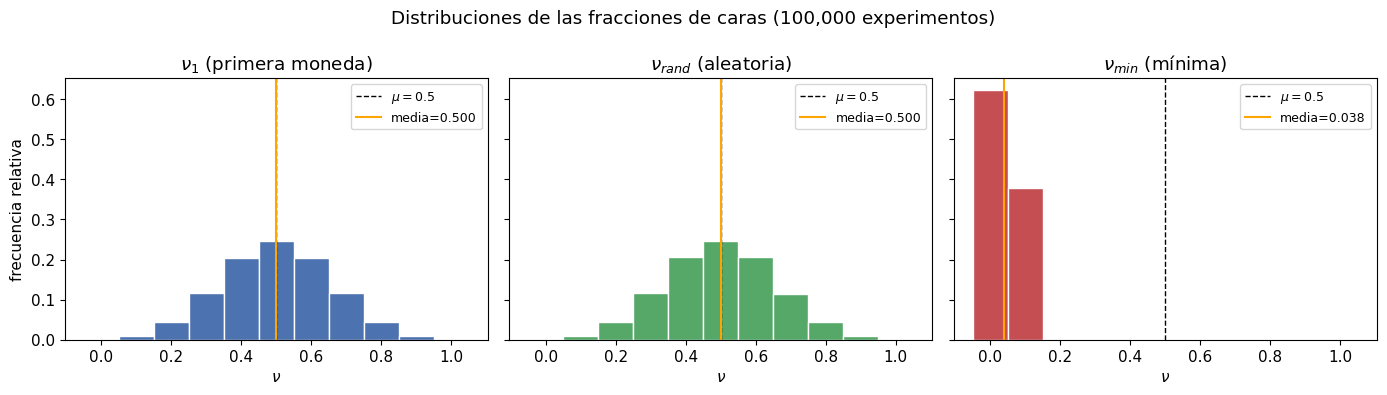

In [4]:
bins = np.arange(-0.05, 1.15, 0.1)          # centrar barras en 0.0,0.1,...,1.0
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
data   = [nu_1, nu_rand, nu_min]
titles = [r"$\nu_1$ (primera moneda)", r"$\nu_{rand}$ (aleatoria)", r"$\nu_{min}$ (mínima)"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

for ax, d, t, c in zip(axes, data, titles, colors):
    ax.hist(d, bins=bins, weights=np.ones_like(d)/len(d), color=c, edgecolor="white")
    ax.axvline(0.5, color="k", ls="--", lw=1, label=r"$\mu=0.5$")
    ax.axvline(d.mean(), color="orange", ls="-", lw=1.5, label=f"media={d.mean():.3f}")
    ax.set_title(t); ax.set_xlabel(r"$\nu$"); ax.legend(fontsize=9)
axes[0].set_ylabel("frecuencia relativa")
plt.suptitle("Distribuciones de las fracciones de caras (100,000 experimentos)")
plt.tight_layout(); plt.show()

**Lectura de los histogramas.** $\nu_1$ y $\nu_\text{rand}$ tienen esencialmente la **misma** distribución binomial(10, 0.5)/10, centrada en 0.5. Esto tiene sentido: fijar "la primera moneda" o "una moneda al azar" son ambas reglas que **no miran los datos**, así que ambas dan una moneda justa típica.

$\nu_\text{min}$ es completamente distinta: es el **mínimo de 1000 variables**, por lo que su masa se concentra en 0.0 y 0.1. Elegir "la moneda con menos caras" es una regla que **sí mira los datos**, y sesga fuertemente hacia abajo el valor observado.

## (c) $\mathbb{P}[\,|\nu-\mu|>\epsilon\,]$ vs. el límite de Hoeffding

Para cada moneda estimamos empíricamente la probabilidad de cola
$$\widehat{\mathbb{P}}[\,|\nu-\mu|>\epsilon\,]=\frac{1}{N_\text{exp}}\sum_{k}\mathbb{1}\big[\,|\nu^{(k)}-0.5|>\epsilon\,\big]$$
y la comparamos con el límite de Hoeffding $2e^{-2\epsilon^2 N}$ con $N=10$.

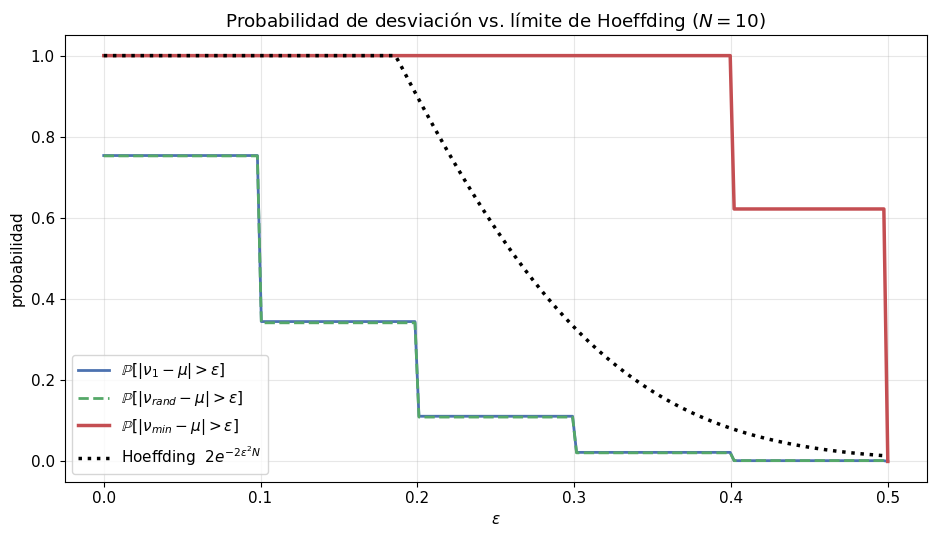

In [5]:
def tail_prob(nu_samples, eps_grid, mu=MU):
    dev = np.abs(nu_samples - mu)
    # P[|nu-mu| > eps] para cada eps
    return np.array([(dev > e).mean() for e in eps_grid])

eps = np.linspace(0, 0.5, 200)
hoeffding = np.minimum(2 * np.exp(-2 * eps**2 * N_FLIPS), 1.0)   # el bound nunca excede 1

p1    = tail_prob(nu_1,    eps)
prand = tail_prob(nu_rand, eps)
pmin  = tail_prob(nu_min,  eps)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(eps, p1,    color="#4C72B0", lw=2, label=r"$\mathbb{P}[|\nu_1-\mu|>\epsilon]$")
ax.plot(eps, prand, color="#55A868", lw=2, ls="--", label=r"$\mathbb{P}[|\nu_{rand}-\mu|>\epsilon]$")
ax.plot(eps, pmin,  color="#C44E52", lw=2.5, label=r"$\mathbb{P}[|\nu_{min}-\mu|>\epsilon]$")
ax.plot(eps, hoeffding, color="black", lw=2.5, ls=":", label=r"Hoeffding  $2e^{-2\epsilon^2 N}$")

ax.set_xlabel(r"$\epsilon$"); ax.set_ylabel("probabilidad")
ax.set_title("Probabilidad de desviación vs. límite de Hoeffding ($N=10$)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

En muchos casos ayuda ver el eje $y$ en **escala logarítmica** para apreciar que $c_\text{min}$ rompe el límite por órdenes de magnitud, mientras $c_1$ y $c_\text{rand}$ quedan holgadamente por debajo.

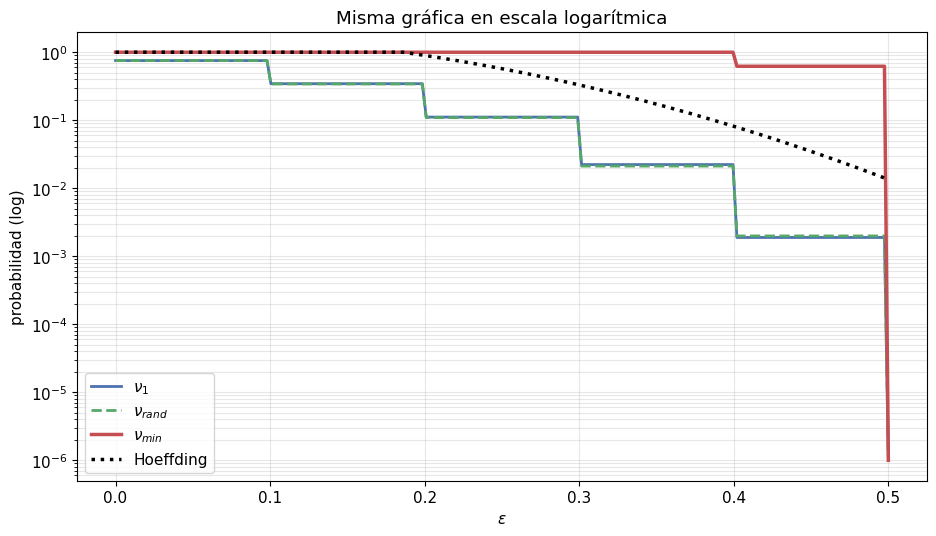

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.semilogy(eps, np.clip(p1,    1e-6, 1), color="#4C72B0", lw=2, label=r"$\nu_1$")
ax.semilogy(eps, np.clip(prand, 1e-6, 1), color="#55A868", lw=2, ls="--", label=r"$\nu_{rand}$")
ax.semilogy(eps, np.clip(pmin,  1e-6, 1), color="#C44E52", lw=2.5, label=r"$\nu_{min}$")
ax.semilogy(eps, hoeffding, color="black", lw=2.5, ls=":", label="Hoeffding")
ax.set_xlabel(r"$\epsilon$"); ax.set_ylabel("probabilidad (log)")
ax.set_title("Misma gráfica en escala logarítmica")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## (d) ¿Qué monedas obedecen el límite de Hoeffding y cuáles no?

| Moneda | ¿Obedece Hoeffding? | Por qué |
|---|---|---|
| $c_1$ | **Sí** | Se fija *antes* de lanzar. Es una hipótesis única fija ⇒ Hoeffding aplica directamente. |
| $c_\text{rand}$ | **Sí** | El índice al azar es independiente de los resultados de los lanzamientos, así que también es una moneda "fija" desde el punto de vista estadístico. |
| $c_\text{min}$ | **No** | Se elige *después* de ver los datos, buscando explícitamente la de menor $\nu$. Esto sesga $\nu_\text{min}$ hacia 0 y su cola supera con creces $2e^{-2\epsilon^2N}$. |

**Explicación.** El límite de Hoeffding vale para una hipótesis **fijada de antemano** (o, con la corrección de la unión, para un conjunto finito de hipótesis simultáneamente). $c_1$ y $c_\text{rand}$ cumplen esa condición. Pero $c_\text{min}$ es el resultado de una **optimización sobre 1000 monedas**: estamos preguntando "¿cuál es la peor de las 1000?", y siempre hay alguna extrema. Formalmente, para $c_\text{min}$ el límite correcto no es el de una sola urna sino el de la **unión** sobre las $M=1000$ urnas:

$$\mathbb{P}\Big[\max_m |\nu_m-\mu|>\epsilon\Big]\ \le\ 2M\,e^{-2\epsilon^2 N}.$$

Ese límite de la unión (con $M=1000$) sí acota a $c_\text{min}$, aunque de forma mucho más floja.

## (e) Relación con las múltiples urnas de la Figura 1.10

La Figura 1.10 muestra $M$ urnas, una por cada hipótesis $h_1,\dots,h_M$, cada una con su $E_\text{in}(h_m)$ (muestra) y su $E_\text{out}(h_m)$ (verdad). El paralelismo con este experimento es directo:

- **Cada moneda ≙ una urna ≙ una hipótesis $h_m$.** Aquí hay $M=1000$ urnas.
- **$\nu_m$ (fracción de caras) ≙ $E_\text{in}(h_m)$** — el error/estadístico observado *en la muestra* de $N=10$ ejemplos.
- **$\mu=0.5$ ≙ $E_\text{out}(h_m)$** — el valor real, que no depende de la muestra.
- Lanzar 10 veces cada moneda ≙ evaluar cada hipótesis sobre un conjunto de $N=10$ datos.

**La moraleja del aprendizaje.** Elegir $c_\text{min}$ es exactamente lo que hace un algoritmo de aprendizaje: **selecciona la hipótesis con menor error en la muestra** ($\min_m E_\text{in}$). Igual que $\nu_\text{min}\approx 0$ engaña ($E_\text{in}$ bajo) mientras $\mu=0.5$ sigue siendo alto ($E_\text{out}$ alto), un algoritmo puede encontrar una $g$ con $E_\text{in}(g)$ pequeño que no garantiza $E_\text{out}(g)$ pequeño. Por eso, cuando elegimos entre $M$ hipótesis, el límite de Hoeffding de una sola urna ya no basta y hay que usar el límite de la unión:

$$\mathbb{P}\big[\,|E_\text{in}(g)-E_\text{out}(g)|>\epsilon\,\big]\ \le\ 2M\,e^{-2\epsilon^2 N}.$$

Este es precisamente el paso conceptual entre la Figura 1.10 y la desigualdad (1.6) del libro: pasar de una hipótesis a muchas cuesta un factor $M$, y ese factor es el precio de "mirar los datos" para elegir la hipótesis. Más adelante, la dimensión VC reemplaza ese $M$ (que puede ser infinito) por una cantidad efectiva finita.

## Resumen

- **(a)** $\mu=0.5$ para las tres monedas (todas son justas).
- **(b)** $\nu_1$ y $\nu_\text{rand}$ se distribuyen alrededor de 0.5; $\nu_\text{min}$ se concentra cerca de 0.
- **(c)** Las colas de $\nu_1$ y $\nu_\text{rand}$ quedan bajo $2e^{-2\epsilon^2N}$; la de $\nu_\text{min}$ lo excede.
- **(d)** $c_1$ y $c_\text{rand}$ obedecen Hoeffding; $c_\text{min}$ no, porque se elige tras ver los datos.
- **(e)** $c_\text{min}$ es análoga a elegir la hipótesis de menor $E_\text{in}$ entre $M$ urnas ⇒ se necesita el límite de la unión $2Me^{-2\epsilon^2N}$.